# Stage 1 — EEG motor-imagery decoder

Train a CSP + LDA decoder on day 1 of BCI Competition IV 2a (BNCI2014_001), calibrate it, and test on day 2.
Outputs: `summary_by_subject.csv` and every figure in `figures/`.

In [1]:
# %pip install -r requirements.txt   

In [2]:
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import mne
from moabb.datasets import BNCI2014_001
from mne.decoding import CSP
from sklearn.pipeline import Pipeline
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.model_selection import train_test_split
from sklearn.calibration import CalibratedClassifierCV
from sklearn.metrics import cohen_kappa_score, confusion_matrix

%matplotlib inline
warnings.filterwarnings("ignore", message="Montage name 'standard_1005' is deprecated")
mne.set_log_level("WARNING")

SEED = 20260901
FIG = Path("figures")
FIG.mkdir(exist_ok=True)

# plot colours
BLUE, ORANGE, GREEN, GREY = "#2a78d6", "#eb6834", "#1baf7a", "#8a8985"

print(f"mne {mne.__version__} | seed {SEED}")

mne 1.13.2 | seed 20260901


## Visualise the data

=== Recording Overview ===
Sampling frequency: 250.0 Hz


Total duration:     386.94 s (96735 samples)
EEG channels (22): Fz, FC3, FC1, FCz, FC2, FC4, C5, C3, C1, Cz, C2, C4, C6, CP3, CP1, CPz, CP2, CP4, P1, Pz, P2, POz


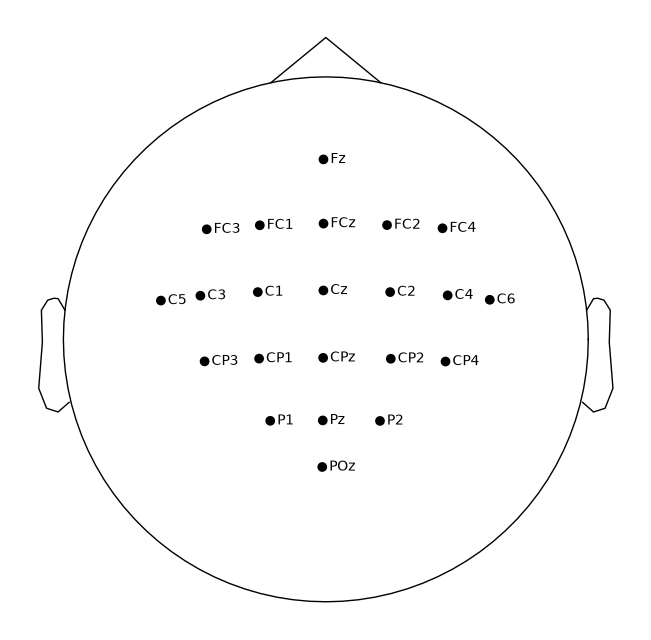

In [3]:
# subject 3, day 1, run 0
dataset = BNCI2014_001()
data = dataset.get_data(subjects=[3])

raw = data[3]["0train"]["0"].copy()
raw.pick("eeg")  # drop 3 EOG channels

print("=== Recording Overview ===")
print(f"Sampling frequency: {raw.info['sfreq']} Hz")
print(f"Total duration:     {raw.times[-1]:.2f} s ({len(raw.times)} samples)")
print(f"EEG channels ({raw.info['nchan']}): {', '.join(raw.ch_names)}")

# electrode positions
fig = raw.plot_sensors(show_names=True, show=False)
fig.savefig(FIG / "fig01_sensor_layout.png", dpi=200, bbox_inches="tight")
plt.show()

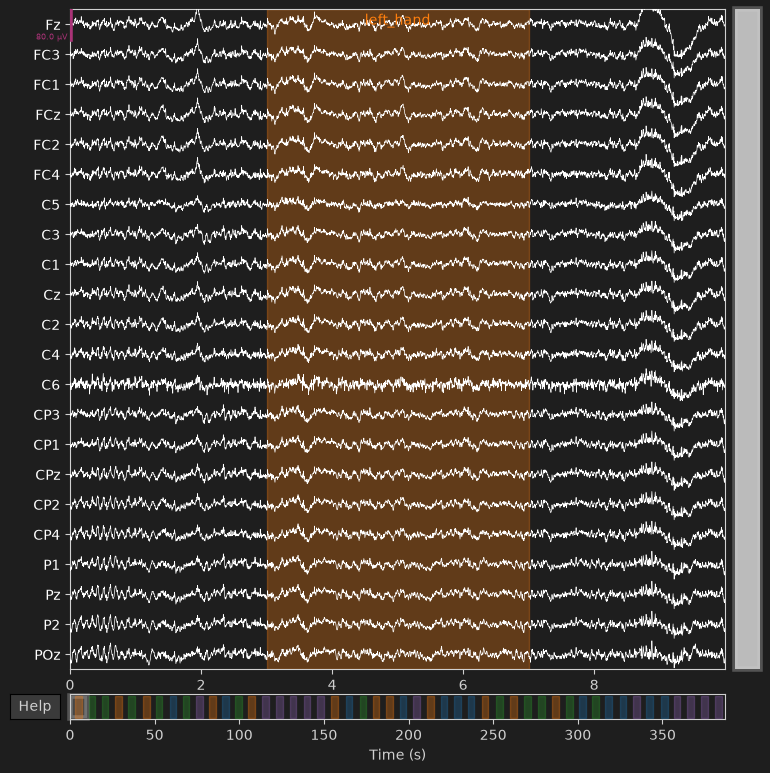

In [4]:
# raw EEG, first 10 s of all 22 channels, drawn inside the notebook
with mne.viz.use_browser_backend("matplotlib"):
    fig = raw.plot(duration=10.0, n_channels=22, scalings={"eeg": 40e-6}, show=False)
fig.savefig(FIG / "fig02_raw_eeg.png", dpi=200, bbox_inches="tight")
plt.show()

# set True to also open the scrollable MNE window (the run pauses until you close it)
POPUP = False
if POPUP:
    raw.plot(duration=10.0, n_channels=22, scalings={"eeg": 40e-6}, block=True)

# understanding the data 

It contains recordings from 9 subjects performing four different imagined movements:

* Left hand
* Right hand
* Both feet
* Tongue

the reason we pick the dataset is we can map the left hand and right hand to tuen left and right etc and feet to move forward and tongue to stop.

The EEG was recorded using 22 EEG channels at a sampling rate of 250 Hz. The recordings also contain 3 EOG channels for detecting eye-related activity and a stimulus channel containing event information.

In the following code, we will inspect how MOABB loads the dataset, how the raw EEG is stored, how annotations and events identify the motor-imagery trials, and finally how the continuous EEG is converted into epochs (X) and labels (y) for machine learning.

The basic structure is:

Raw EEG → Events/Annotations → Epochs → X + y

# EEG Bandpass Filtering (8–30 Hz)

: ## Types of Brain Waves

- **Delta (δ): 0.5–4 Hz** — Active mainly during **deep sleep**.
- **Theta (θ): 4–8 Hz** — Common during **drowsiness, light sleep, and deep relaxation**.
- **Alpha (α): 8–13 Hz** — Prominent during **relaxed wakefulness**, especially with eyes closed.
- **Beta (β): 13–30 Hz** — Associated with **active thinking, concentration and during  movement and movement imagination and                               rebound when stop**.
- **Gamma (γ): 30–100 Hz** — Associated with **higher-level information processing and cognitive activity**.


also there is another brian signal **$\mu$ (mu) : 8 -12 Hz** - it associtated with movemnat imagination or performing movement. the alpha and mu has same freq range but the mu wave generate in sensori motor cortex. 

* we need to filter the $\beta$ and $\mu$ rhythm so we set the bandwidth 8-30 hz .





In [5]:
# 4th-order Butterworth, 8-30 Hz
raw.filter(l_freq=8.0, h_freq=30.0, method="iir",
           iir_params={"order": 4, "ftype": "butter"})
print("Filtering complete: 8-30 Hz band-pass applied.")

Filtering complete: 8-30 Hz band-pass applied.


## Lebel

we map 
* 0 - left hand
* 1- right hand
* 2-feet
* 3- tongue

In [6]:
events, event_ids = mne.events_from_annotations(raw)
print("MNE event ids (alphabetical):", event_ids)

CLASSES = ["left_hand", "right_hand", "feet", "tongue"]

# map by name, not number
event_id_to_class_idx = {event_ids[c]: i for i, c in enumerate(CLASSES)}

for mne_id, idx in event_id_to_class_idx.items():
    print(f"MNE ID {mne_id} -> Class {idx} ({CLASSES[idx]})")

MNE event ids (alphabetical): {'feet': 1, 'left_hand': 2, 'right_hand': 3, 'tongue': 4}
MNE ID 2 -> Class 0 (left_hand)
MNE ID 3 -> Class 1 (right_hand)
MNE ID 1 -> Class 2 (feet)
MNE ID 4 -> Class 3 (tongue)


## Cut trial epochs 

the t = 0s , the trial maker place the fixation cross and at t = 2s the visual cue arrow instruct the subject to imagine . so teh subject imagine the at t = 2.5 to 4.5s . we skip the initial 2.5s because the signal mainly due to eye movment (tracked in eog ).  

In [7]:
epochs = mne.Epochs(raw, events, tmin=2.5, tmax=4.5, baseline=None, preload=True, verbose=False)

X = epochs.get_data()  # (trials, channels, time)
y = np.array([event_id_to_class_idx[e] for e in epochs.events[:, 2]])

print(f"X shape: {X.shape}  ->  (trials, channels, time_points)")
print(f"y shape: {y.shape}")
print(f"Class distribution (run 0): {np.bincount(y)}")

X shape: (48, 22, 501)  ->  (trials, channels, time_points)
y shape: (48,)
Class distribution (run 0): [12 12 12 12]


### Concatenate the 6 runs of a session

If a trial's window runs past the end of the recording, MNE drops it. We don't pad with fake data — `kept` marks which trials have real data.

In [8]:
def load_session(subject, session, tmin=2.5, tmax=4.5, return_kept=False):
    runs = BNCI2014_001().get_data(subjects=[subject])[subject][session]
    X_list, y_list, kept_list = [], [], []

    for run_id in sorted(runs):
        r = runs[run_id].copy().pick("eeg")
        r.filter(8.0, 30.0, method="iir", iir_params={"order": 4, "ftype": "butter"}, verbose=False)

        ev, ev_ids = mne.events_from_annotations(r, verbose=False)
        mapping = {ev_ids[c]: i for i, c in enumerate(CLASSES)}

        ep = mne.Epochs(r, ev, tmin=tmin, tmax=tmax, baseline=None, preload=True, verbose=False)
        kept = np.zeros(len(ev), dtype=bool)
        kept[ep.selection] = True  # surviving trials

        X_list.append(ep.get_data())
        y_list.append(np.array([mapping[e] for e in ev[:, 2]]))
        kept_list.append(kept)

    X = np.concatenate(X_list)
    y_all = np.concatenate(y_list)
    kept = np.concatenate(kept_list)

    if return_kept:
        return X, y_all, kept
    return X, y_all[kept]

## Fit the model (subject 3)

In [9]:
def make_pipeline():
    return Pipeline([
        ("csp", CSP(n_components=6, log=True, norm_trace=False)),
        ("lda", LinearDiscriminantAnalysis(solver="lsqr", shrinkage="auto")),
    ])

# day 1 = train, day 2 = test
X_train, y_train = load_session(3, "0train")
X_test, y_test = load_session(3, "1test")

# day 1: 75% fit, 25% calibration
X_fit, X_calib, y_fit, y_calib = train_test_split(
    X_train, y_train, test_size=0.25, stratify=y_train, random_state=SEED)

print(f"Fitting trials:     {len(y_fit)} {np.bincount(y_fit)}")
print(f"Calibration trials: {len(y_calib)} {np.bincount(y_calib)}")
print(f"Day 2 test trials:  {len(y_test)}")

pipe = make_pipeline().fit(X_fit, y_fit)
print(f"\nRaw test accuracy (day 2): {pipe.score(X_test, y_test):.3f}")

Fitting trials:     216 [54 54 54 54]
Calibration trials: 72 [18 18 18 18]
Day 2 test trials:  288



Raw test accuracy (day 2): 0.708


### Probability calibration and confidence

In [10]:
def calibrate(pipe, X_calib, y_calib):
    # Platt scaling, CSP/LDA stay frozen
    try:
        from sklearn.frozen import FrozenEstimator
        model = CalibratedClassifierCV(FrozenEstimator(pipe), method="sigmoid")
    except ImportError:
        model = CalibratedClassifierCV(estimator=pipe, cv="prefit", method="sigmoid")
    return model.fit(X_calib, y_calib)

calibrated_model = calibrate(pipe, X_calib, y_calib)

proba = calibrated_model.predict_proba(X_test)
pred, conf = proba.argmax(1), proba.max(1)

print(f"Calibrated accuracy: {np.mean(pred == y_test):.3f}")
print(f"Cohen's kappa:       {cohen_kappa_score(y_test, pred):.3f}")

Calibrated accuracy: 0.691
Cohen's kappa:       0.588


### Expected Calibration Error (ECE)

In [11]:
def compute_ece(conf, pred, y_true, n_bins=10):
    # sum over bins of |accuracy - confidence| * bin share
    correct = (pred == y_true).astype(float)
    edges = np.linspace(0, 1, n_bins + 1)
    ece = 0.0
    for i in range(n_bins):
        lo, hi = edges[i], edges[i + 1]
        m = (conf >= lo) & (conf <= hi) if i == 0 else (conf > lo) & (conf <= hi)
        if m.any():
            ece += m.mean() * abs(correct[m].mean() - conf[m].mean())
    return float(ece)

raw_proba = pipe.predict_proba(X_test)
print(f"Raw ECE:        {compute_ece(raw_proba.max(1), raw_proba.argmax(1), y_test):.3f}")
print(f"Calibrated ECE: {compute_ece(conf, pred, y_test):.3f}")

Raw ECE:        0.146
Calibrated ECE: 0.044


### Decision latency

Slide the 2 s window over 0–4 s after the cue (0.1 s steps). Latency = end of the first window whose top-class probability reaches 0.5.
Trials that never get there — or have no data for the long window (last trial of each run) — are **censored** at 4 s.

In [12]:
def sliding_latency(model, X_long, kept, sfreq=250, win_s=2.0, step_s=0.1,
                    threshold=0.5, horizon=4.0):
    win, step = int(win_s * sfreq), int(step_s * sfreq)
    kept_idx = np.flatnonzero(kept)  # X_long row -> trial index
    latencies = np.full(len(kept), horizon)
    reached = np.zeros(len(kept), dtype=bool)

    for start in range(0, X_long.shape[2] - win + 1, step):
        top = model.predict_proba(X_long[:, :, start:start + win]).max(1)
        rows = kept_idx[(top >= threshold) & ~reached[kept_idx]]
        latencies[rows] = (start + win) / sfreq  # window end
        reached[rows] = True
        if reached[kept_idx].all():
            break

    return latencies, ~reached  # latencies, censored

# 0-4 s post-cue = 2-6 s from trial start
X_long, y_long, kept = load_session(3, "1test", tmin=2.0, tmax=6.0, return_kept=True)
print(f"X_long: {X_long.shape} (kept {kept.sum()} of {len(kept)} trials)")

latencies, censored = sliding_latency(calibrated_model, X_long, kept)
print(f"Median latency:    {np.median(latencies):.2f} s")
print(f"Censored fraction: {censored.mean():.3f}")

X_long: (282, 22, 1001) (kept 282 of 288 trials)


Median latency:    2.00 s
Censored fraction: 0.021


# Results — all 9 subjects

Each subject's outputs are kept in `results[sub]`, so the figures below always use the right subject.

In [13]:
def evaluate_subject(sub):
    X_tr, y_tr = load_session(sub, "0train")
    X_te, y_te = load_session(sub, "1test")
    X_f, X_c, y_f, y_c = train_test_split(X_tr, y_tr, test_size=0.25,
                                          stratify=y_tr, random_state=SEED)
    p = make_pipeline().fit(X_f, y_f)
    cal = calibrate(p, X_c, y_c)

    raw_pr, cal_pr = p.predict_proba(X_te), cal.predict_proba(X_te)
    X_l, _, k = load_session(sub, "1test", tmin=2.0, tmax=6.0, return_kept=True)
    lat, cens = sliding_latency(cal, X_l, k)

    summary = {
        "subject": sub,
        "raw_acc": np.mean(raw_pr.argmax(1) == y_te),
        "calib_acc": np.mean(cal_pr.argmax(1) == y_te),
        "kappa": cohen_kappa_score(y_te, cal_pr.argmax(1)),
        "raw_ece": compute_ece(raw_pr.max(1), raw_pr.argmax(1), y_te),
        "calib_ece": compute_ece(cal_pr.max(1), cal_pr.argmax(1), y_te),
        "median_latency": np.median(lat),
        "censored_fraction": cens.mean(),
    }
    return {"pipe": p, "y_test": y_te, "raw_proba": raw_pr, "cal_proba": cal_pr,
            "latencies": lat, "censored": cens, "summary": summary}


results = {}
for sub in range(1, 10):
    results[sub] = evaluate_subject(sub)
    s = results[sub]["summary"]
    print(f"S{sub}: acc {s['calib_acc']:.3f} | kappa {s['kappa']:.3f} | "
          f"latency {s['median_latency']:.2f} s | censored {s['censored_fraction']:.3f}")

df_summary = pd.DataFrame([r["summary"] for r in results.values()])
df_summary.round(4).to_csv("summary_by_subject.csv", index=False)
df_summary.round(3)

S1: acc 0.556 | kappa 0.407 | latency 2.00 s | censored 0.125


S2: acc 0.556 | kappa 0.407 | latency 3.55 s | censored 0.458


S3: acc 0.691 | kappa 0.588 | latency 2.00 s | censored 0.021


S4: acc 0.389 | kappa 0.185 | latency 4.00 s | censored 1.000


S5: acc 0.191 | kappa -0.079 | latency 4.00 s | censored 0.924


S6: acc 0.378 | kappa 0.171 | latency 4.00 s | censored 0.826


S7: acc 0.396 | kappa 0.194 | latency 2.00 s | censored 0.024


S8: acc 0.497 | kappa 0.329 | latency 3.70 s | censored 0.403


S9: acc 0.337 | kappa 0.116 | latency 4.00 s | censored 0.990


,subject,raw_acc,calib_acc,kappa,raw_ece,calib_ece,median_latency,censored_fraction
0,1,0.576,0.556,0.407,0.138,0.150,2.00,0.125
1,2,0.611,0.556,0.407,0.150,0.075,3.55,0.458
2,3,0.708,0.691,0.588,0.146,0.044,2.00,0.021
3,4,0.389,0.389,0.185,0.142,0.077,4.00,1.000
4,5,0.312,0.191,-0.079,0.148,0.144,4.00,0.924
5,6,0.368,0.378,0.171,0.188,0.030,4.00,0.826
6,7,0.469,0.396,0.194,0.299,0.188,2.00,0.024
7,8,0.535,0.497,0.329,0.091,0.094,3.70,0.403
8,9,0.378,0.337,0.116,0.157,0.063,4.00,0.990


In [14]:
# mean ± std across subjects
# latency not averaged: 5 subjects sit on the 4 s cap
cols = ["raw_acc", "calib_acc", "kappa", "raw_ece", "calib_ece", "censored_fraction"]
df_summary[cols].agg(["mean", "std"]).round(3)

,raw_acc,calib_acc,kappa,raw_ece,calib_ece,censored_fraction
mean,0.483,0.443,0.258,0.162,0.096,0.530
std,0.133,0.147,0.197,0.057,0.053,0.415


## Plotting output

### Results table

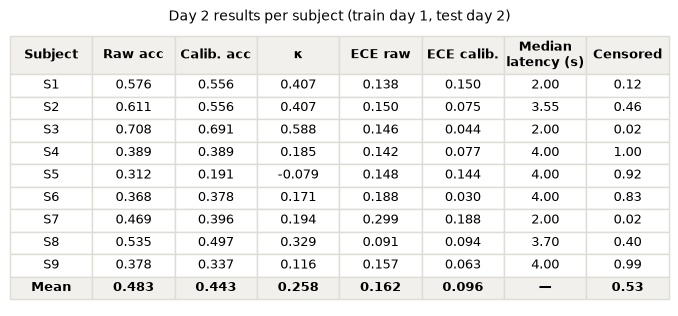

In [15]:
df = df_summary
rows = [[f"S{int(r.subject)}", f"{r.raw_acc:.3f}", f"{r.calib_acc:.3f}", f"{r.kappa:.3f}",
         f"{r.raw_ece:.3f}", f"{r.calib_ece:.3f}", f"{r.median_latency:.2f}",
         f"{r.censored_fraction:.2f}"] for r in df.itertuples()]
m = df.mean()
rows.append(["Mean", f"{m.raw_acc:.3f}", f"{m.calib_acc:.3f}", f"{m.kappa:.3f}",
             f"{m.raw_ece:.3f}", f"{m.calib_ece:.3f}", "—", f"{m.censored_fraction:.2f}"])
headers = ["Subject", "Raw acc", "Calib. acc", "κ", "ECE raw", "ECE calib.",
           "Median\nlatency (s)", "Censored"]

fig, ax = plt.subplots(figsize=(8.5, 3.6))
ax.axis("off")
tbl = ax.table(cellText=rows, colLabels=headers, loc="center", cellLoc="center")
tbl.auto_set_font_size(False)
tbl.set_fontsize(9)
tbl.scale(1, 1.35)
for (r, c), cell in tbl.get_celld().items():
    cell.set_edgecolor("#dedcd6")
    if r == 0:
        cell.set_height(cell.get_height() * 1.7)
    if r in (0, len(rows)):
        cell.set_text_props(weight="bold")
        cell.set_facecolor("#f1f0ec")
ax.set_title("Day 2 results per subject (train day 1, test day 2)", fontsize=10)
fig.savefig(FIG / "fig03_results_table.png", dpi=300, bbox_inches="tight")
plt.show()

### Day 2 performance and calibration, all subjects

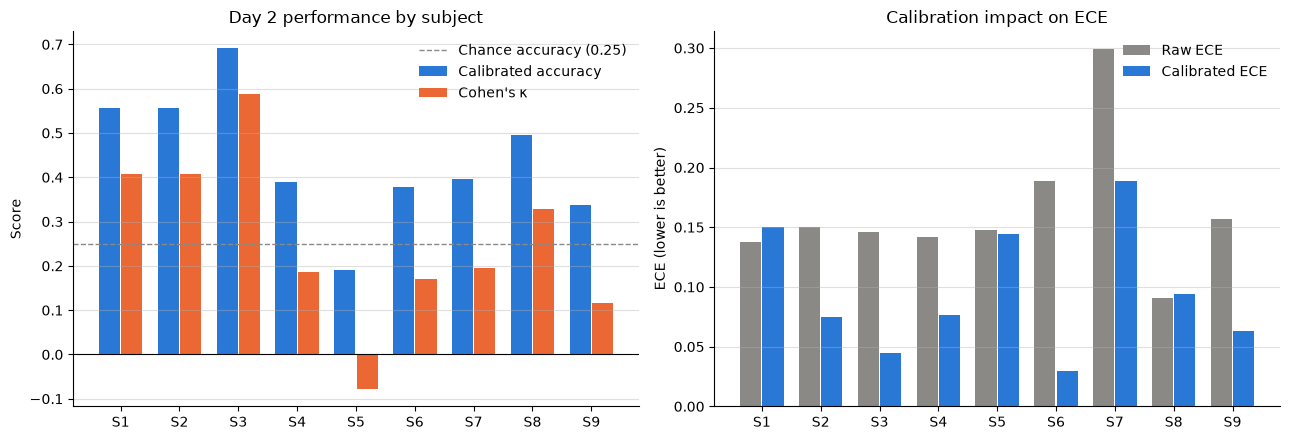

In [16]:
x = np.arange(len(df))
w = 0.36
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

# accuracy and kappa
axes[0].bar(x - w/2 - 0.01, df.calib_acc, w, color=BLUE, label="Calibrated accuracy")
axes[0].bar(x + w/2 + 0.01, df.kappa, w, color=ORANGE, label="Cohen's κ")
axes[0].axhline(0.25, color=GREY, ls="--", lw=1, label="Chance accuracy (0.25)")
axes[0].axhline(0, color="black", lw=0.8)
axes[0].set(ylabel="Score", title="Day 2 performance by subject")

# ECE before/after
axes[1].bar(x - w/2 - 0.01, df.raw_ece, w, color=GREY, label="Raw ECE")
axes[1].bar(x + w/2 + 0.01, df.calib_ece, w, color=BLUE, label="Calibrated ECE")
axes[1].set(ylabel="ECE (lower is better)", title="Calibration impact on ECE")

for ax in axes:
    ax.set_xticks(x, [f"S{s}" for s in df.subject])
    ax.legend(frameon=False)
    ax.grid(axis="y", alpha=0.4)
    ax.spines[["top", "right"]].set_visible(False)
fig.tight_layout()
fig.savefig(FIG / "fig04_performance_and_ece.png", dpi=300, bbox_inches="tight")
plt.show()

### Reliability diagram (subject 3)

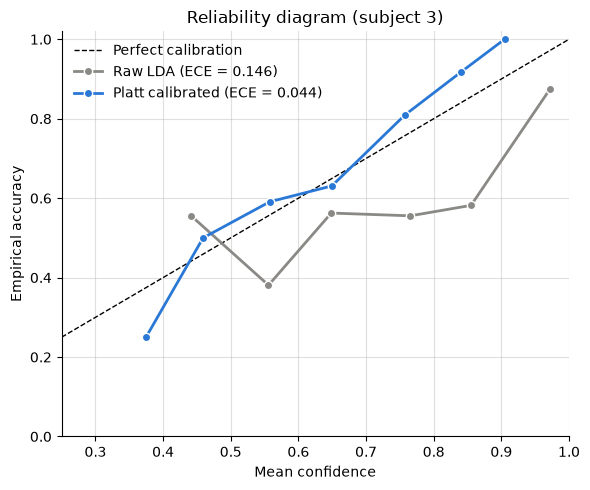

In [17]:
def reliability_curve(conf, pred, y_true, n_bins=10):
    correct = (pred == y_true).astype(float)
    edges = np.linspace(0, 1, n_bins + 1)
    confs, accs = [], []
    for i in range(n_bins):
        lo, hi = edges[i], edges[i + 1]
        m = (conf >= lo) & (conf <= hi) if i == 0 else (conf > lo) & (conf <= hi)
        if m.any():
            confs.append(conf[m].mean())
            accs.append(correct[m].mean())
    return confs, accs

r3 = results[3]
fig, ax = plt.subplots(figsize=(6, 5))
ax.plot([0.25, 1], [0.25, 1], "k--", lw=1, label="Perfect calibration")
for name, pr, color, key in [("Raw LDA", r3["raw_proba"], GREY, "raw_ece"),
                             ("Platt calibrated", r3["cal_proba"], BLUE, "calib_ece")]:
    c, a = reliability_curve(pr.max(1), pr.argmax(1), r3["y_test"])
    ax.plot(c, a, "o-", color=color, lw=2, mec="white",
            label=f"{name} (ECE = {r3['summary'][key]:.3f})")
ax.set(xlim=(0.25, 1), ylim=(0, 1.02), xlabel="Mean confidence",
       ylabel="Empirical accuracy", title="Reliability diagram (subject 3)")
ax.legend(loc="upper left", frameon=False)
ax.grid(alpha=0.4)
ax.spines[["top", "right"]].set_visible(False)
fig.tight_layout()
fig.savefig(FIG / "fig05_reliability_s3.png", dpi=300, bbox_inches="tight")
plt.show()

### Decision latency profile

Censored trials are not counted as decided, so each curve stops at (1 − censored fraction).

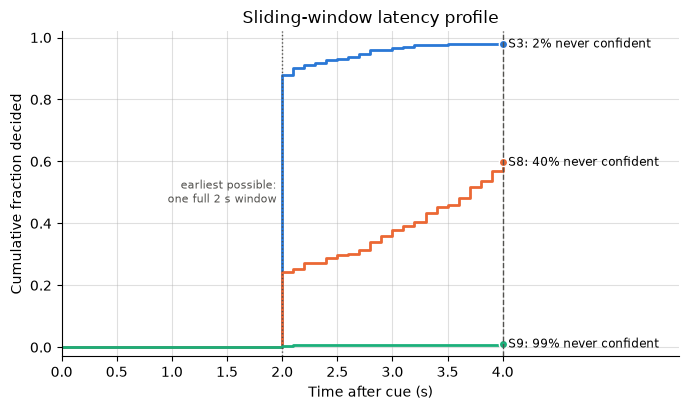

In [18]:
fig, ax = plt.subplots(figsize=(7, 4.2))

for s, color in [(3, BLUE), (8, ORANGE), (9, GREEN)]:
    r = results[s]
    n = len(r["latencies"])
    done = np.sort(r["latencies"][~r["censored"]])
    t = np.r_[0, done, 4.0]
    frac = np.r_[0, np.arange(1, len(done) + 1) / n, len(done) / n]
    ax.step(t, frac, where="post", color=color, lw=2)
    ax.plot(4.0, frac[-1], "o", color=color, mec="white")
    ax.text(4.05, frac[-1], f"S{s}: {r['censored'].mean():.0%} never confident",
            va="center", fontsize=8.5)

ax.axvline(2.0, color="#52514e", ls=":", lw=1)
ax.text(1.95, 0.5, "earliest possible:\none full 2 s window", ha="right",
        va="center", fontsize=8, color="#52514e")
ax.axvline(4.0, color="#52514e", ls="--", lw=1)
ax.set(xlim=(0, 5.6), ylim=(-0.03, 1.02), xticks=np.arange(0, 4.01, 0.5),
       xlabel="Time after cue (s)", ylabel="Cumulative fraction decided",
       title="Sliding-window latency profile")
ax.grid(alpha=0.4)
ax.spines[["top", "right"]].set_visible(False)
fig.tight_layout()
fig.savefig(FIG / "fig06_latency_profile.png", dpi=300, bbox_inches="tight")
plt.show()

### CSP spatial patterns (subject 3)

Should sit over motor cortex (C3, Cz, C4). Uses the fitted decoder's own CSP.

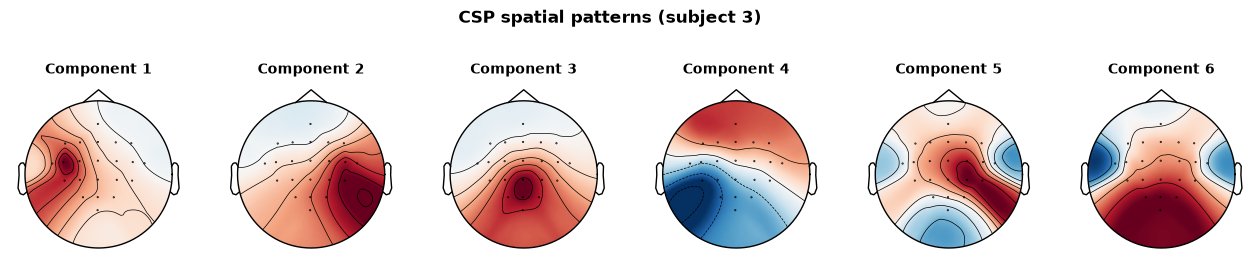

In [19]:
patterns = results[3]["pipe"].named_steps["csp"].patterns_  # (6, 22)

fig, axes = plt.subplots(1, 6, figsize=(16, 3.2))
for i, ax in enumerate(axes):
    mne.viz.plot_topomap(patterns[i], raw.info, axes=ax, show=False, cmap="RdBu_r")
    ax.set_title(f"Component {i + 1}", fontsize=10, fontweight="bold")
fig.suptitle("CSP spatial patterns (subject 3)", fontsize=12, fontweight="bold")
fig.savefig(FIG / "fig07_csp_patterns_s3.png", dpi=300, bbox_inches="tight")
plt.show()

### Median latency vs calibrated accuracy

Note: a median of 4.00 s means the decoder was mostly never confident (censored), not that it was slow.

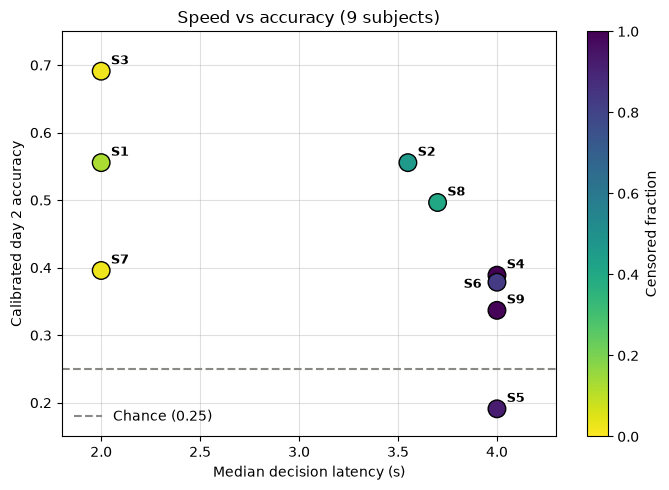

In [20]:
fig, ax = plt.subplots(figsize=(7, 5))
sc = ax.scatter(df.median_latency, df.calib_acc, c=df.censored_fraction, s=160,
                cmap="viridis_r", vmin=0, vmax=1, edgecolor="black", zorder=3)
fig.colorbar(sc, ax=ax, label="Censored fraction")

nudge = {6: (-24, -4)}  # avoid overlap with S4
for r in df.itertuples():
    ax.annotate(f"S{int(r.subject)}", (r.median_latency, r.calib_acc), textcoords="offset points",
                xytext=nudge.get(int(r.subject), (7, 5)), fontsize=9, fontweight="bold")

ax.axhline(0.25, color=GREY, ls="--", label="Chance (0.25)")
ax.set(xlabel="Median decision latency (s)", ylabel="Calibrated day 2 accuracy",
       title="Speed vs accuracy (9 subjects)", ylim=(0.15, 0.75), xlim=(1.8, 4.3))
ax.legend(loc="lower left", frameon=False)
ax.grid(alpha=0.4)
fig.tight_layout()
fig.savefig(FIG / "fig08_speed_accuracy.png", dpi=300, bbox_inches="tight")
plt.show()

### ECE before vs after calibration

Points below the diagonal improved.

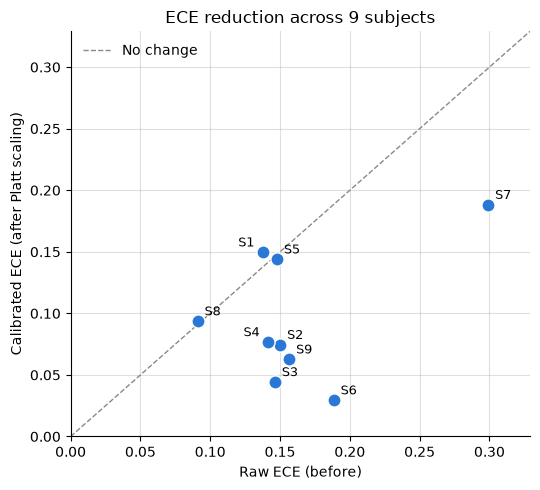

In [21]:
fig, ax = plt.subplots(figsize=(5.5, 5))
lim = max(df.raw_ece.max(), df.calib_ece.max()) + 0.03
ax.plot([0, lim], [0, lim], "--", color=GREY, lw=1, label="No change")
ax.scatter(df.raw_ece, df.calib_ece, s=90, color=BLUE, edgecolor="white", zorder=3)
nudge = {1: (-18, 4), 4: (-18, 4)}  # avoid overlaps
for r in df.itertuples():
    ax.annotate(f"S{int(r.subject)}", (r.raw_ece, r.calib_ece), textcoords="offset points",
                xytext=nudge.get(int(r.subject), (5, 4)), fontsize=9)
ax.set(xlim=(0, lim), ylim=(0, lim), xlabel="Raw ECE (before)",
       ylabel="Calibrated ECE (after Platt scaling)", title="ECE reduction across 9 subjects")
ax.legend(frameon=False)
ax.grid(alpha=0.4)
ax.spines[["top", "right"]].set_visible(False)
fig.tight_layout()
fig.savefig(FIG / "fig09_ece_before_after.png", dpi=300, bbox_inches="tight")
plt.show()

### Normalized 4-class confusion matrices

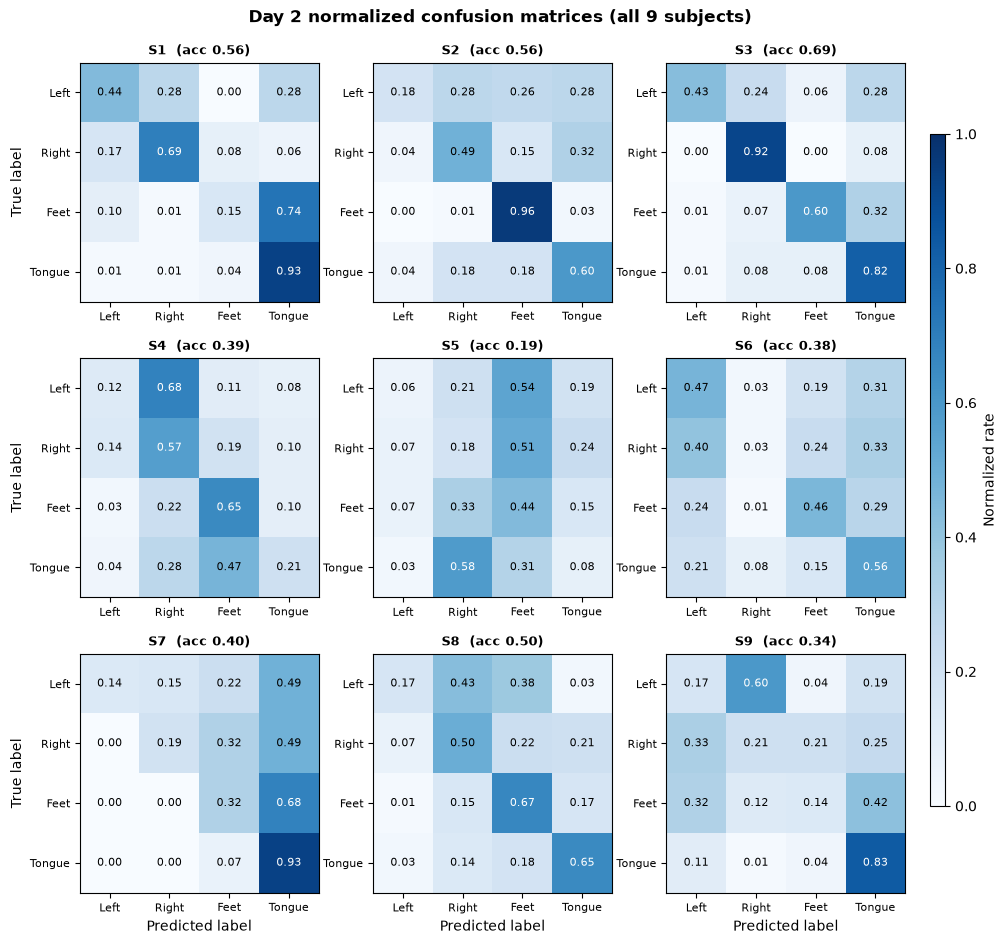

In [22]:
labels = ["Left", "Right", "Feet", "Tongue"]
fig, axes = plt.subplots(3, 3, figsize=(10, 9.6))

for ax, (s, r) in zip(axes.ravel(), results.items()):
    cm = confusion_matrix(r["y_test"], r["cal_proba"].argmax(1), normalize="true")
    im = ax.imshow(cm, cmap="Blues", vmin=0, vmax=1)
    ax.set_xticks(range(4), labels, fontsize=8)
    ax.set_yticks(range(4), labels, fontsize=8)
    ax.set_title(f"S{s}  (acc {r['summary']['calib_acc']:.2f})", fontsize=9, fontweight="bold")
    for i in range(4):
        for j in range(4):
            ax.text(j, i, f"{cm[i, j]:.2f}", ha="center", va="center", fontsize=8,
                    color="white" if cm[i, j] > 0.55 else "black")

for ax in axes[:, 0]:
    ax.set_ylabel("True label")
for ax in axes[-1]:
    ax.set_xlabel("Predicted label")

fig.tight_layout(rect=(0, 0, 0.92, 0.96))
fig.colorbar(im, cax=fig.add_axes([0.93, 0.15, 0.015, 0.7]), label="Normalized rate")
fig.suptitle("Day 2 normalized confusion matrices (all 9 subjects)", fontsize=12, fontweight="bold")
fig.savefig(FIG / "fig10_confusion_matrices.png", dpi=300, bbox_inches="tight")
plt.show()